In [235]:
print("hello world")

hello world


In [237]:
from models.analyzer import FeatureSelectionAnalyzer

In [238]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

In [239]:
data = pd.read_excel("./data_raw/DataSet_V49 (2).xlsx")

In [257]:
for col in data.columns:
    if "GRACE" in col or "TIMI" in col:
        print(col)

TIMI
GRACE(Общее)
TIMI (Летальность)


In [243]:
data.dropna(subset=['Смерть'], inplace=True)
data['Смерть'] = data['Смерть'].map({'Да': 1, 'Нет': 0})

In [5]:
cols = [
    "Смерть",
    "Age",
    "Sex",
    "Рост",
    "Вес",
    "Индекс массы тела", 
    "Инфаркт миокарда в анамнезе (<3)",
    "Инфаркт миокарда в анамнезе (>3)",
    "Инфаркт миокарда со стентированием в анамнезе",
    "ОНМК (иш) в анамнезе",
    "ОНМК (гем) в анамнезе",
    "Стентирование в анамнезе",
    "Открытая перация на сердце в анамнезе",
    "ГБ стадия",
    "ГБ риск",
    "АГ",
    "СД",
    "ХБП",
    "ЯБ",
    "МКБ",
    "ЖКБ",
    "ХОБЛ (Новый столбец)",
    "Курит",
    "Экстракардиальная артериопатия",
    "Плохая мобильность",
    "Стенокардия (ИБ)",
    "Стенокардия форма(ИБ)",
    "Стенокардия ФК (ИБ)",
    "Стенокардия в диагнозе при поступлении",
    "ПИКС в диагнозе при поступлении",
    "Форма ФП",
    "ФП постоянная форма",
    "ФП при окс (до чкв)", 
    "ЧКВ",
    "Инфаркт-зависимая артерия",
    "Поражение ствола",
    "Количество пораженных сосудов(Syntax)",
    "Количество пораженных сосудов(Значимость)",
    "TIMI",
    "Класс ОСН по Killip",
    "ХСН стадия",
    "ФЖ",
    "Пробежки ЖТ",
    "Рецидивирующая ЖТ",
    "Срочность",
    "Экстренная операция(ИБ)(Новый)",
    "Вид операции(ИБ)(Новый)",
    "Тромболизис",
    "Медицинская помощь оказана за первые 4 часа",
    "Гипертоническая болезнь",
    "ФВ < 40",
    "А-В блокада",
    "А-В блокада (степень)",
]

In [244]:
category_cols = [
    "Sex", "STEMI", "ЧКВ", "Вид STEMI", "Инфаркт-зависимая артерия",
    "Поражение ствола","Инфаркт миокарда в анамнезе (<3)",
    "Инфаркт миокарда в анамнезе (>3)",'Инфаркт миокарда со стентированием в анамнезе',
    'ОНМК (иш) в анамнезе', 'ОНМК (гем) в анамнезе','Стентирование в анамнезе',
    'Тромболизис', 'Форма ФП', 'Калий', 'Дилатация предсердий','ФП b (после чкв)',
    'ФП a (в анамнезе)', 'ФП при окс (до чкв)', 'ФП постоянная форма', 'ФЖ',
    'Пробежки ЖТ', 'Рецидивирующая ЖТ', 'MKB', 'Класс ОСН по Killip',
    'ХСН стадия', 'АГ', 'Стенокардия (ИБ)', 'Стенокардия форма(ИБ)',
    'Стенокардия ФК (ИБ)', 'СД', 'ХБП', 'ЯБ', 'МКБ', 'ЖКБ', 'Стеноз аортального клапана (степень)',
    'Недостаточность трикуспидального клапана (степень)', 'НПВ', 'Экстренная операция(ИБ)(Новый)',
    'Вид операции(ИБ)(Новый)', 'повторные операции','Тип первой операции БД',
    'Тип повторной операции', 'GRACE(Общее)>140', 'интегрилин|эптифибатид|коромакс|агграстат',
    'Экстракардиальная артериопатия', 'Плохая мобильность', 'Открытая перация на сердце в анамнезе',
    'Срочность', 'Сопутствующие1', 'Сопутствующие2', 'Тропонин 1 > 0.1 (b)', 'Тропонин 1 > 0.1 (a)',
    'Тропонин 1 > 0.1', 'Smoking', 'Протокол коронарографии', 'Аортальный стеноз (Градиент)',
    'Аортальный стеноз (Заключение)', 'ХОБЛ (Новый столбец)', 'Коррекция А-В блокады',
    'Исход А-В блокады', 'Начало А-В блокады (До/после ЧКВ)', 'А-В блокада',
    'Стенокардия в диагнозе при поступлении', 'ПИКС в диагнозе при поступлении',
    'Инфаркт-зависимая артерия(Огригированная)', 'Инфаркт-зависимая артерия(Огригированная)2',
    'Ишемический инсульт (Выгрузка из ИБ - временный столбец)', 'Геморрагический инсульт (Выгрузка из ИБ - временный столбец)',
    'Инсульт (Выгрузка из ИБ - временный столбец)', 'Курит', 'GRACE(Общее)>156', 'Отек легких(b)',
    'Отек легких(a)', 'Отек легких', 'Медицинская помощь оказана за первые 4 часа',
    'Гипертоническая болезнь', 'ФВ < 40', 'CADILLAC (Низкий риск)', 'CADILLAC (Средний риск)',
    'CADILLAC (Высокий риск)', 'РЕКОРД (Низкий риск)', 'РЕКОРД (Высокий риск)',
    'GRACE (Низкий риск)', 'GRACE (Средний риск)', 'GRACE (Высокий риск)',
    'TIMI (Летальность) (Низкий риск)', 'TIMI (Летальность) (Средний риск)',
    'TIMI (Летальность) (Высокий риск)', 'PAMI (Низкий риск)', 'PAMI (Средний риск)',
    'PAMI (Высокий риск)', 'А-В блокаДа (Новый)', 'А-В блокада (степень)',
    'Используемый антибиотик ДО развития SOFA 8 и более',
    'Левофлоксацин антибиотик ДО развития SOFA 8 и более',
    'Линезолид антибиотик ДО развития SOFA 8 и более',
    'Меропенем антибиотик ДО развития SOFA 8 и более',
    'Метронидазол антибиотик ДО развития SOFA 8 и более',
    'Моксифлоксацин антибиотик ДО развития SOFA 8 и более',
    'Нифуроксазид антибиотик ДО развития SOFA 8 и более',
    'Фосфомицин антибиотик ДО развития SOFA 8 и более',
    'Цефазолин антибиотик ДО развития SOFA 8 и более',
    'Сульбактам антибиотик ДО развития SOFA 8 и более',
    'Цефоперазон антибиотик ДО развития SOFA 8 и более',
    'Цефтриаксон антибиотик ДО развития SOFA 8 и более',
    'Антибиотик после развития SOFA 8 и более',
    'Моксифлоксацин после развития SOFA 8 и более',
    'Левофлоксацин после развития SOFA 8 и более',
    'Азитромицин после развития SOFA 8 и более',
    'Линезолид после развития SOFA 8 и более',
    'Меропенем после развития SOFA 8 и более',
    'Метронидазол после развития SOFA 8 и более',
    'Нифуроксазид после развития SOFA 8 и более',
    'Фосфомицин после развития SOFA 8 и более',
    'Цефазолин после развития SOFA 8 и более',
    'Сульбактам после развития SOFA 8 и более',
    'Цефепим после развития SOFA 8 и более',
    'Цефтриаксон после развития SOFA 8 и более',
    'ИВЛ', 'Вазопрессорная поддержка', 'Адреналин',
    'Добутамин', 'Допмин', 'Норадреналин', 'Левосимендан',
    'Мезатон', 'UA (нестабильная стенокардия)','Синдромный диагноз','Смерть'
]

In [245]:
cols_to_delete = [
    "Код пациента", "Name", "Дата STEMI", "Дата направления (Общий анализ крови)", 
    "Дата взятия биоматериала (Общий анализ крови)", "Дата выполнения (Общий анализ крови)", 
    "Дата направления (Общий анализ крови-экспрес)", "Дата взятия биоматериала (Общий анализ крови-экспрес)",
    "Дата выполнения (Общий анализ крови-экспрес)", "Начало операции(ИБ)(Новый)", "Конец операции(ИБ)(Новый)", 
    "дата поступления", "дата выписки", "дата смерти", "Исход заболевания", "Поступление в реанимацию", 
    "Выписка из реанимации", "Файл(Анализы)", "Файл(ИБ)","Наличие в БД", "Наличие в файле", "Bypass#", 
    "Повторная оперция", "Смерть в реанимации", "Причина смерти", "Осложнения", "SmokeIndex", "Ход операции", 
    "Общий анализ крови раньше операции", "Общий анализ крови_экспресс раньше операции", "Отделение", 
    "Запись требует проверки", "Индекс курения", "Летальный исход икка", "Диагноз", 
    "Дата и время развития SOFA 8 и более", "Время введения первого антибиотика", 
    "Набор данных (Данные Кокарев)", "Unnamed: 344", "В базе данных", 
    "SYNTAX Score", "ХСН фк", "КДР ЛЖ", "КСР ЛЖ", "ДАД(a)", "Кардиогенный шок",
    'длительность нахождения в стационаре',
    'GRACE(Общее)>140',
    'GRACE(Общее)>156',
    'Отек легких(b)',
    'Отек легких(a)', 'Отек легких',
    'CADILLAC (Низкий риск)', 'CADILLAC (Средний риск)',
    'CADILLAC (Высокий риск)', 'РЕКОРД (Низкий риск)', 'РЕКОРД (Высокий риск)',
    'GRACE (Низкий риск)', 'GRACE (Средний риск)', 'GRACE (Высокий риск)',
    'TIMI (Летальность) (Низкий риск)', 'TIMI (Летальность) (Средний риск)',
    'TIMI (Летальность) (Высокий риск)', 'PAMI (Низкий риск)', 'PAMI (Средний риск)',
    'PAMI (Высокий риск)',
    'МКБ', 'ЖКБ',
    'Протокол коронарографии',
    'Класс ОСН по Killip',
    'ФВ < 40',
    "Мочевина(a)"
    
]

In [246]:
for col in cols_to_delete:
    try:
        data.drop([col], axis=1, inplace=True)
    except Exception as e: 
        pass 

In [247]:
for col in category_cols:
    if col not in cols_to_delete:
        data[col] = data[col].fillna('missing').astype('str')
        data[col] = data[col].astype('category')

In [248]:
X = data.drop(["Смерть"], axis=1)
y = data["Смерть"].astype('int')

In [249]:
def clean_column_names(df):
    """
    Очищает имена колонок от символов, которые не принимает XGBoost
    """
    new_columns = []
    for col in df.columns:
        # Удаляем запрещенные символы
        clean_col = col.replace('[', '_').replace(']', '_').replace('<', '_lt_')
        # Удаляем другие потенциально проблемные символы
        clean_col = clean_col.replace('>', '_gt_').replace(' ', '_').replace(':', '_')
        clean_col = clean_col.replace('(', '_').replace(')', '_').replace(',', '_')
        clean_col = clean_col.replace('{', '_').replace('}', '_').replace('|', '_')
        # Удаляем последовательные подчеркивания
        clean_col = '_'.join(filter(None, clean_col.split('_')))
        # Удаляем подчеркивания в начале и конце
        clean_col = clean_col.strip('_')
        # Если имя начинается с цифры, добавляем префикс
        if clean_col and clean_col[0].isdigit():
            clean_col = 'f_' + clean_col
        new_columns.append(clean_col)
    
    # Создаем копию DataFrame с новыми именами колонок
    df_clean = df.copy()
    df_clean.columns = new_columns
    return df_clean

# Применяем к вашим данным
X_clean = clean_column_names(X)

In [250]:
cat_features = []
for col in X_clean.columns:
    try:
        if X_clean[col].dtype.name == 'category': 
            cat_features.append(col)
    except Exception as e:
        print(col)

In [14]:
cat_features

['Sex',
 'STEMI',
 'ЧКВ',
 'Вид_STEMI',
 'Инфаркт-зависимая_артерия',
 'Поражение_ствола',
 'Инфаркт_миокарда_в_анамнезе_lt_3',
 'Инфаркт_миокарда_в_анамнезе_gt_3',
 'Инфаркт_миокарда_со_стентированием_в_анамнезе',
 'ОНМК_иш_в_анамнезе',
 'ОНМК_гем_в_анамнезе',
 'Стентирование_в_анамнезе',
 'Тромболизис',
 'Форма_ФП',
 'Калий',
 'Дилатация_предсердий',
 'ФП_b_после_чкв',
 'ФП_a_в_анамнезе',
 'ФП_при_окс_до_чкв',
 'ФП_постоянная_форма',
 'ФЖ',
 'Пробежки_ЖТ',
 'Рецидивирующая_ЖТ',
 'MKB',
 'Класс_ОСН_по_Killip',
 'ХСН_стадия',
 'АГ',
 'Стенокардия_ИБ',
 'Стенокардия_форма_ИБ',
 'Стенокардия_ФК_ИБ',
 'СД',
 'ХБП',
 'ЯБ',
 'МКБ',
 'ЖКБ',
 'Стеноз_аортального_клапана_степень',
 'Недостаточность_трикуспидального_клапана_степень',
 'НПВ',
 'Экстренная_операция_ИБ_Новый',
 'Вид_операции_ИБ_Новый',
 'повторные_операции',
 'Тип_первой_операции_БД',
 'Тип_повторной_операции',
 'GRACE_Общее_gt_140',
 'интегрилин_эптифибатид_коромакс_агграстат',
 'Экстракардиальная_артериопатия',
 'Плохая_мобильно

In [251]:
analyzer = FeatureSelectionAnalyzer(X_clean, y, test_size=0.2, random_state=42, categorial_features=cat_features)

In [252]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import lightgbm
import time

In [253]:
scale_pos_weight = len(y[y == 0]) / max(1, len(y[y == 1]))
class_weight_dict = {0: 1, 1: scale_pos_weight}

print(f"scale pos weight: {scale_pos_weight}")

scale pos weight: 27.89217391304348


In [17]:
list(X.select_dtypes(include=['category']).columns)

['Sex',
 'STEMI',
 'ЧКВ',
 'Вид STEMI',
 'Инфаркт-зависимая артерия',
 'Поражение ствола',
 'Инфаркт миокарда в анамнезе (<3)',
 'Инфаркт миокарда в анамнезе (>3)',
 'Инфаркт миокарда со стентированием в анамнезе',
 'ОНМК (иш) в анамнезе',
 'ОНМК (гем) в анамнезе',
 'Стентирование в анамнезе',
 'Тромболизис',
 'Форма ФП',
 'Калий',
 'Дилатация предсердий',
 'ФП b (после чкв)',
 'ФП a (в анамнезе)',
 'ФП при окс (до чкв)',
 'ФП постоянная форма',
 'ФЖ',
 'Пробежки ЖТ',
 'Рецидивирующая ЖТ',
 'MKB',
 'Класс ОСН по Killip',
 'ХСН стадия',
 'АГ',
 'Стенокардия (ИБ)',
 'Стенокардия форма(ИБ)',
 'Стенокардия ФК (ИБ)',
 'СД',
 'ХБП',
 'ЯБ',
 'МКБ',
 'ЖКБ',
 'Стеноз аортального клапана (степень)',
 'Недостаточность трикуспидального клапана (степень)',
 'НПВ',
 'Экстренная операция(ИБ)(Новый)',
 'Вид операции(ИБ)(Новый)',
 'повторные операции',
 'Тип первой операции БД',
 'Тип повторной операции',
 'GRACE(Общее)>140',
 'интегрилин|эптифибатид|коромакс|агграстат',
 'Экстракардиальная артериопати

In [254]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # борьба с дисбалансом
    missing=np.nan,  # явно указываем, что NaN - это пропуски
    random_state=42,
    eval_metric='logloss',  # для бинарной классификации
    tree_method='auto',  # автоматический выбор метода обучения
    enable_categorical=True
)

lgb_model = LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    class_weight=class_weight_dict,  # борьба с дисбалансом
    random_state=42,
    verbose=-1,  # подавляем вывод (задается при инициализации, а не в fit)
    # early_stopping_rounds=50  # задается при инициализации
)

cat_model = CatBoostClassifier(
    iterations=100,
    depth=5,
    learning_rate=0.1,
    class_weights=[1, scale_pos_weight],  # борьба с дисбалансом
    random_state=42,
    verbose=False,
    eval_metric='Logloss',
    early_stopping_rounds=50,  # задается при инициализации
    # cat_features=list(X.select_dtypes(include=['category']).columns)
)

In [255]:
print("=== FORWARD SELECTION ===")
forward_features = analyzer.forward_selection(cat_model, max_features=None, metric='roc_auc')

=== FORWARD SELECTION ===
Запуск Forward Selection...


  0%|          | 1/392 [00:40<4:22:31, 40.29s/it, roc_auc=0.7994, Features=1]

Step 1: Добавлен признак 'Креатинин', roc_auc: 0.7994


  1%|          | 2/392 [01:26<4:43:32, 43.62s/it, roc_auc=0.8714, Features=2]

Step 2: Добавлен признак 'СДЛА', roc_auc: 0.8714


...

Step 8: Добавлен признак 'Apache_II', roc_auc: 0.9637


  2%|▏         | 9/392 [08:26<6:35:46, 62.00s/it, roc_auc=0.9661, Features=9]

Step 9: Добавлен признак 'Тип_повторной_операции', roc_auc: 0.9661


  2%|▏         | 9/392 [09:36<6:48:33, 64.00s/it, roc_auc=0.9661, Features=9]

Step 10: Нет улучшений, останавливаемся
Forward Selection завершен. Выбрано признаков: 9


In [256]:
print("\n=== BACKWARD ELIMINATION ===")
backward_features = analyzer.backward_elimination(cat_model, min_features=1, metric='roc_auc')


=== BACKWARD ELIMINATION ===
Запуск Backward Elimination...


  0%|          | 1/391 [09:05<59:03:24, 545.14s/it, roc_auc=0.9633, Features=391]

Step 1: Удален признак 'Инфаркт-зависимая_артерия_Огригированная', roc_auc: 0.9633


  1%|          | 2/391 [18:09<58:51:15, 544.67s/it, roc_auc=0.9637, Features=390]

Step 2: Удален признак 'РЕКОРД', roc_auc: 0.9637


  1%|          | 3/391 [27:08<58:25:57, 542.16s/it, roc_auc=0.9665, Features=389]

Step 3: Удален признак 'APACHE_сутки_до_развития_SOFA_8_и_более', roc_auc: 0.9665


  1%|          | 3/391 [36:06<77:50:15, 722.20s/it, roc_auc=0.9665, Features=389]

Step 4: Удаление ухудшает результат, останавливаемся
Backward Elimination завершен. Осталось признаков: 389



=== СРАВНЕНИЕ МЕТОДОВ ===


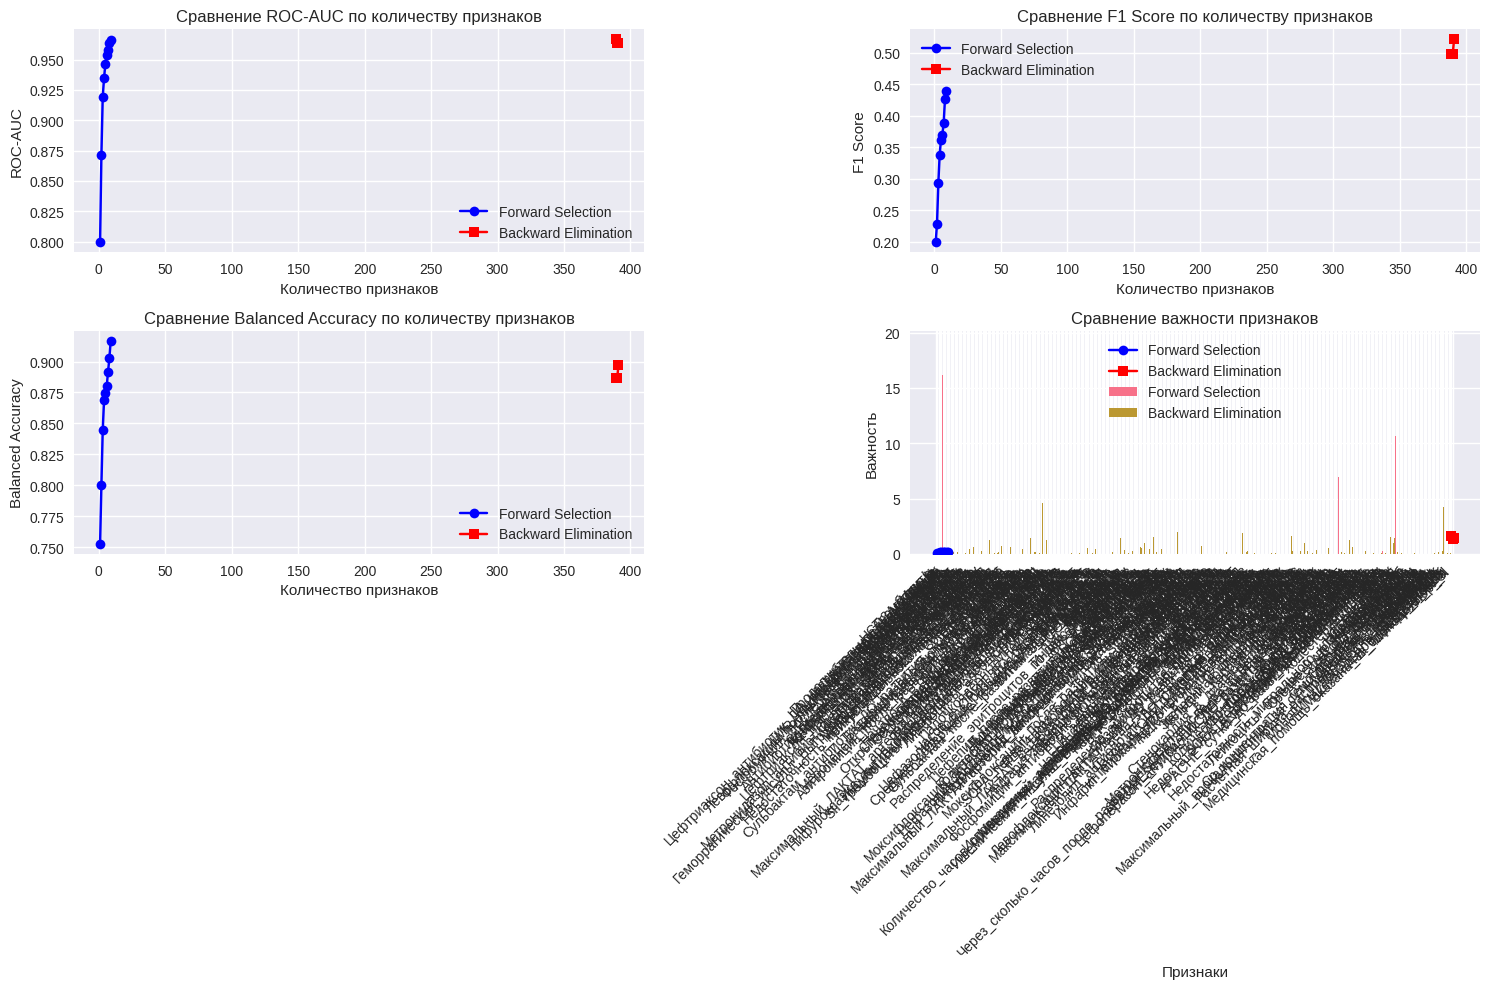

In [258]:
print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
analyzer.compare_feature_selection_methods()

In [259]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='forward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (forward, 9 признаков) ===
По Balanced Accuracy score: 0.5200 (F1=0.9186)
По Youden's J: 0.5203


In [260]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='backward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (backward, 389 признаков) ===
По Balanced Accuracy score: 0.3100 (F1=0.9076)
По Youden's J: 0.3135



=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


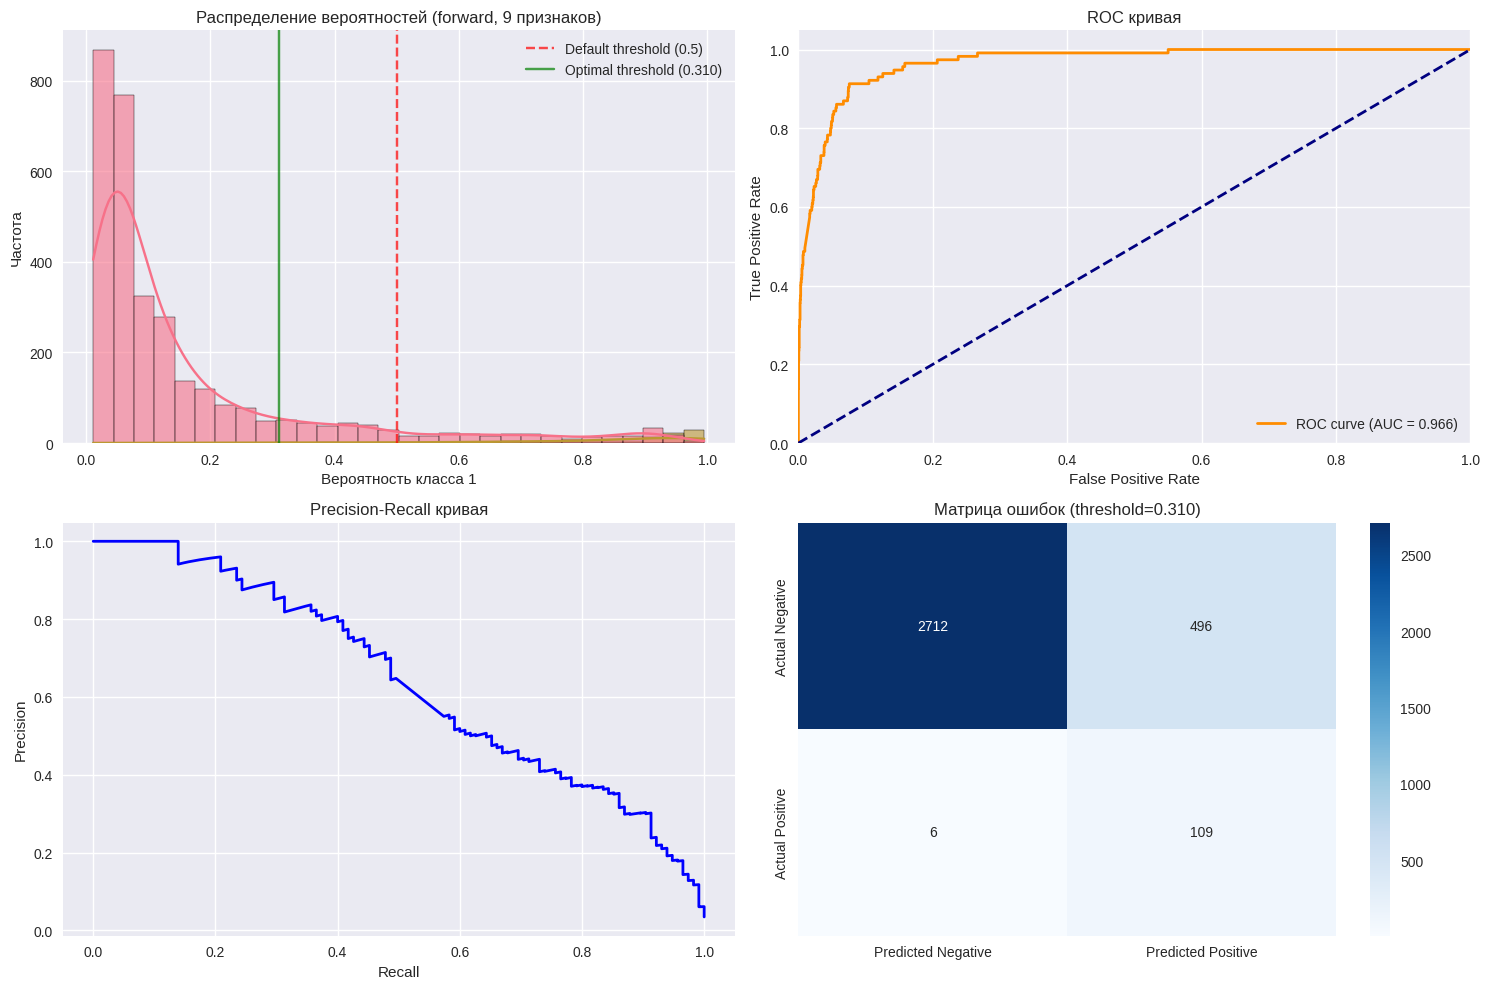

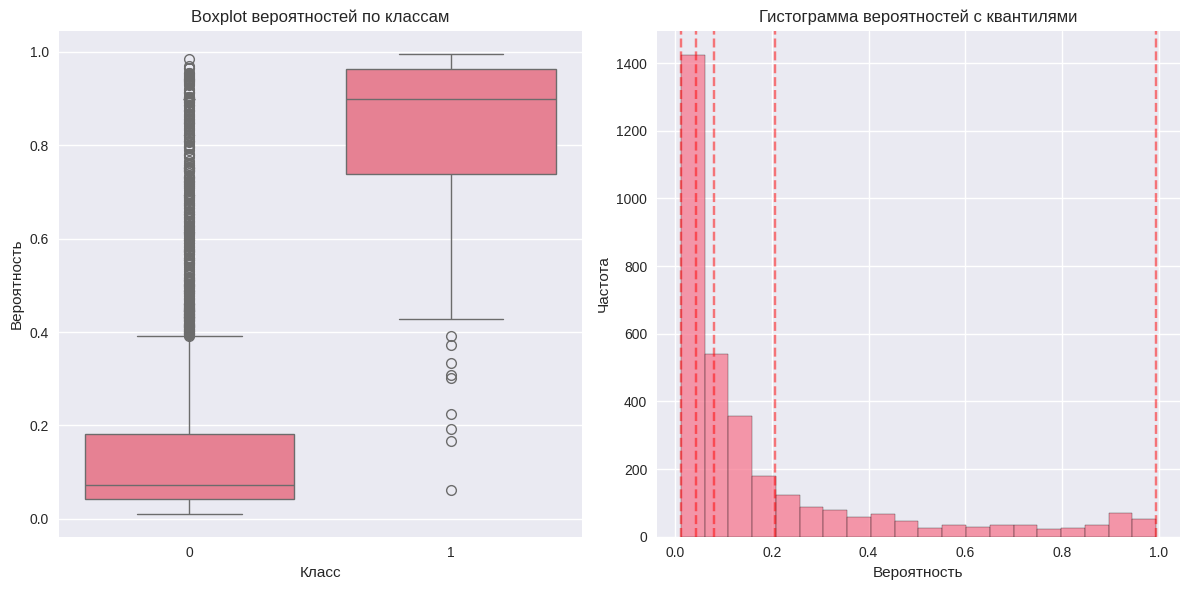

In [261]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='forward')


=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


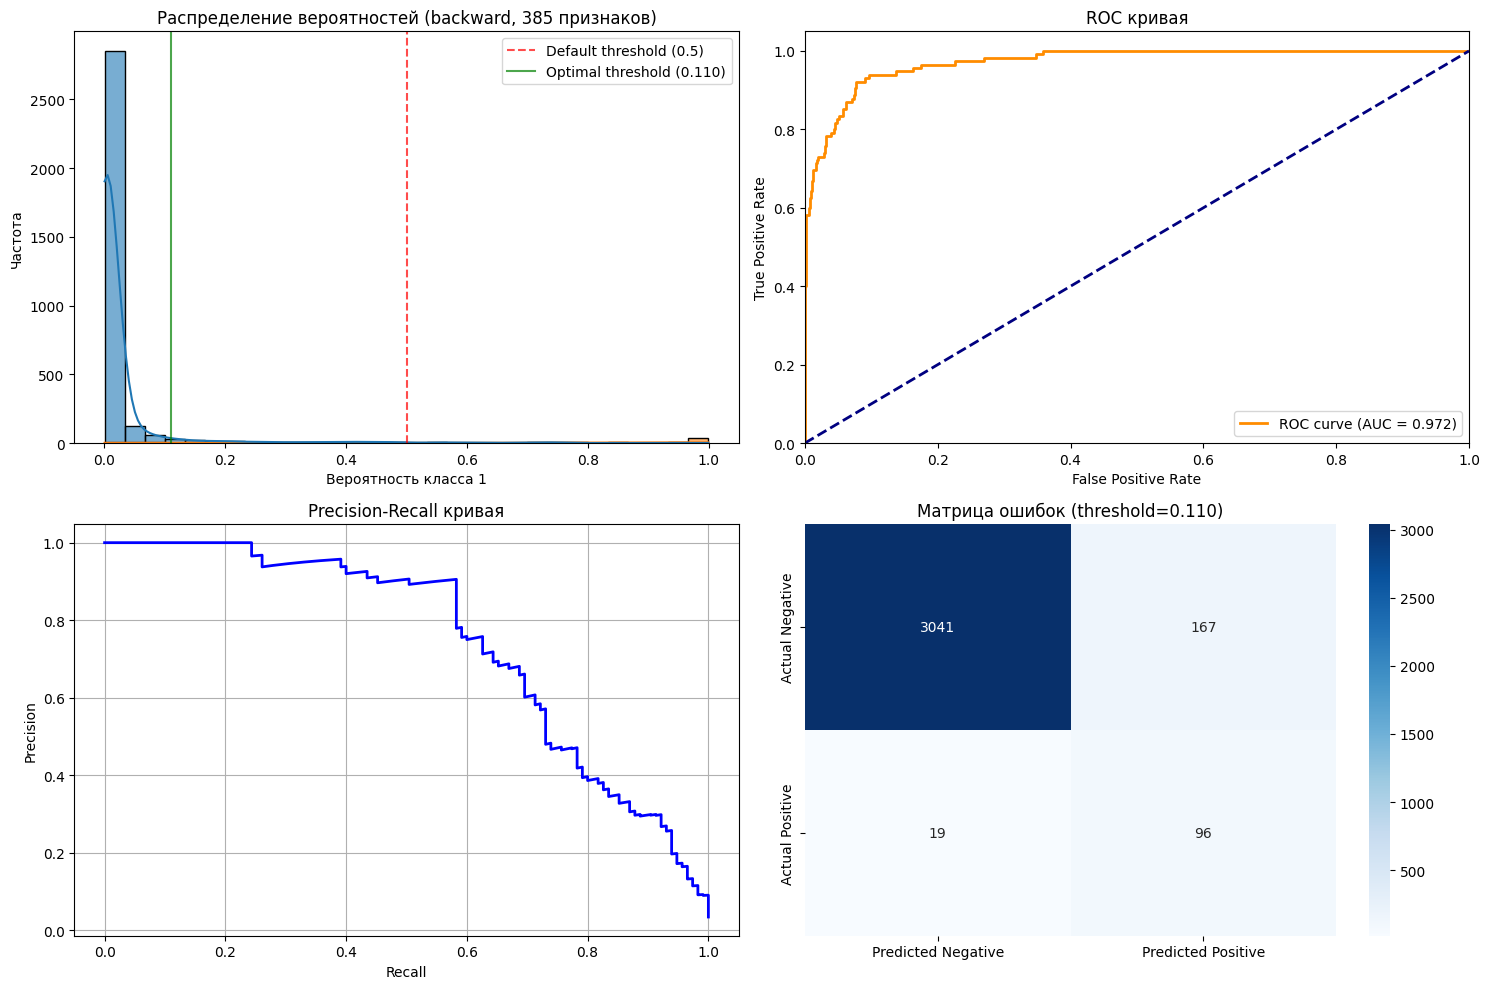

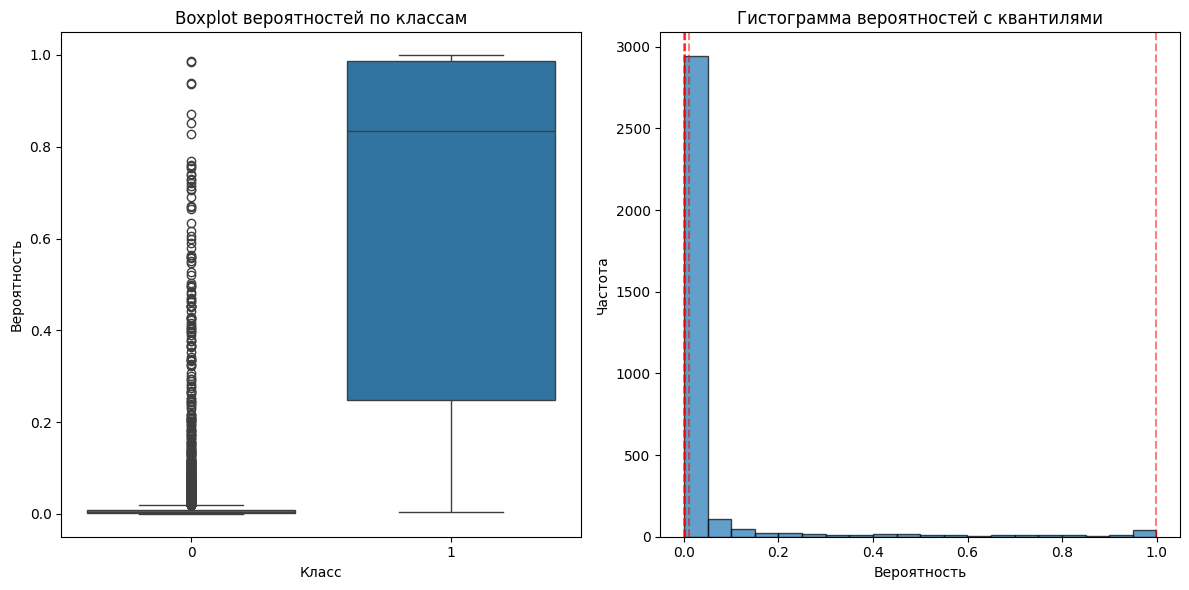

In [76]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='backward')

In [262]:
# Получение лучших признакей из всех комбинаций
print("\n=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===")
best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')


=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===
=== Лучшие признаки (forward) ===
Количество признаков: 9
Лучшая f1: 0.4403
Признаки: ['Креатинин', 'СДЛА', 'UA_нестабильная_стенокардия', 'MKB', 'Нейтрофилы_абсолютное_значение', 'GRACE_Общее', 'Стенокардия_в_диагнозе_при_поступлении', 'Apache_II', 'Тип_повторной_операции']

Важность признаков:
  Нейтрофилы_абсолютное_значение: 19.1871
  СДЛА: 17.1529
  UA_нестабильная_стенокардия: 16.2005
  MKB: 15.9437
  Креатинин: 10.6266
  Apache_II: 6.9711
  Стенокардия_в_диагнозе_при_поступлении: 6.9564
  GRACE_Общее: 6.7025
  Тип_повторной_операции: 0.2592
=== Лучшие признаки (backward) ===
Количество признаков: 391
Лучшая f1: 0.5215
Признаки: ['Age', 'Sex', 'STEMI', 'ЧКВ', 'Вид_STEMI', 'Инфаркт-зависимая_артерия', 'Поражение_ствола', 'Количество_пораженных_сосудов_Syntax', 'Количество_пораженных_сосудов_Значимость', 'TIMI', 'Инфаркт_миокарда_в_анамнезе_lt_3', 'Инфаркт_миокарда_в_анамнезе_gt_3', 'Инфаркт_миокарда_со_стентированием_в_анамнезе', 'ОНМК_и

In [263]:
print("\n=== ЗАКЛЮЧЕНИЕ ===")
print(f"Лучший ROC AUC (Forward): {best_forward_result['metrics']['roc_auc']:.4f} с {len(best_forward_features)} признаками")
print(f"Лучший ROC AUC (Backward): {best_backward_result['metrics']['roc_auc']:.4f} с {len(best_backward_features)} признаками")
print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")


=== ЗАКЛЮЧЕНИЕ ===
Лучший ROC AUC (Forward): 0.9661 с 9 признаками
Лучший ROC AUC (Backward): 0.9633 с 391 признаками
Оптимальный порог для бинарной классификации: 0.3100


-----------------

In [264]:
analyzer = FeatureSelectionAnalyzer(X_clean, y, test_size=0.2, random_state=42, categorial_features=cat_features)

In [265]:
print("=== FORWARD SELECTION ===")
forward_features = analyzer.forward_selection(xgb_model, max_features=None, metric='roc_auc')  # ограничим до 10 признакей для демонстрации

=== FORWARD SELECTION ===
Запуск Forward Selection...


  0%|          | 1/392 [00:20<2:14:26, 20.63s/it, roc_auc=0.7900, Features=1]

Step 1: Добавлен признак 'Креатинин', roc_auc: 0.7900


  1%|          | 2/392 [00:46<2:34:37, 23.79s/it, roc_auc=0.8577, Features=2]

Step 2: Добавлен признак 'СДЛА', roc_auc: 0.8577


...

Step 15: Добавлен признак 'Кальций_ионизированный_Ca+_b', roc_auc: 0.9681


  4%|▍         | 16/392 [09:28<4:21:17, 41.70s/it, roc_auc=0.9681, Features=16]

Step 16: Добавлен признак 'Цефепим_после_развития_SOFA_8_и_более', roc_auc: 0.9681


  4%|▍         | 16/392 [10:12<3:59:51, 38.28s/it, roc_auc=0.9681, Features=16]

Step 17: Нет улучшений, останавливаемся
Forward Selection завершен. Выбрано признаков: 16


In [ ]:
print("\n=== BACKWARD ELIMINATION ===")
backward_features = analyzer.backward_elimination(xgb_model, min_features=1, metric='roc_auc')


=== BACKWARD ELIMINATION ===
Запуск Backward Elimination...


  0%|          | 1/391 [07:18<47:30:09, 438.48s/it, roc_auc=0.9695, Features=391]

Step 1: Удален признак 'СОЭ_a', roc_auc: 0.9695


  1%|          | 2/391 [14:33<47:10:51, 436.64s/it, roc_auc=0.9695, Features=390]

Step 2: Удален признак 'Максимальное_ЧСС_7_сутки', roc_auc: 0.9695


...

Step 9: Удален признак 'ГБ_стадия', roc_auc: 0.9720


  3%|▎         | 10/391 [1:13:57<46:47:45, 442.17s/it, roc_auc=0.9720, Features=382]

Step 10: Удален признак 'Среднее_ЧСС_1_сутки', roc_auc: 0.9720


  3%|▎         | 11/391 [1:21:14<46:29:43, 440.48s/it, roc_auc=0.9720, Features=381]

Step 11: Удален признак 'ФП_постоянная_форма', roc_auc: 0.9720



=== СРАВНЕНИЕ МЕТОДОВ ===


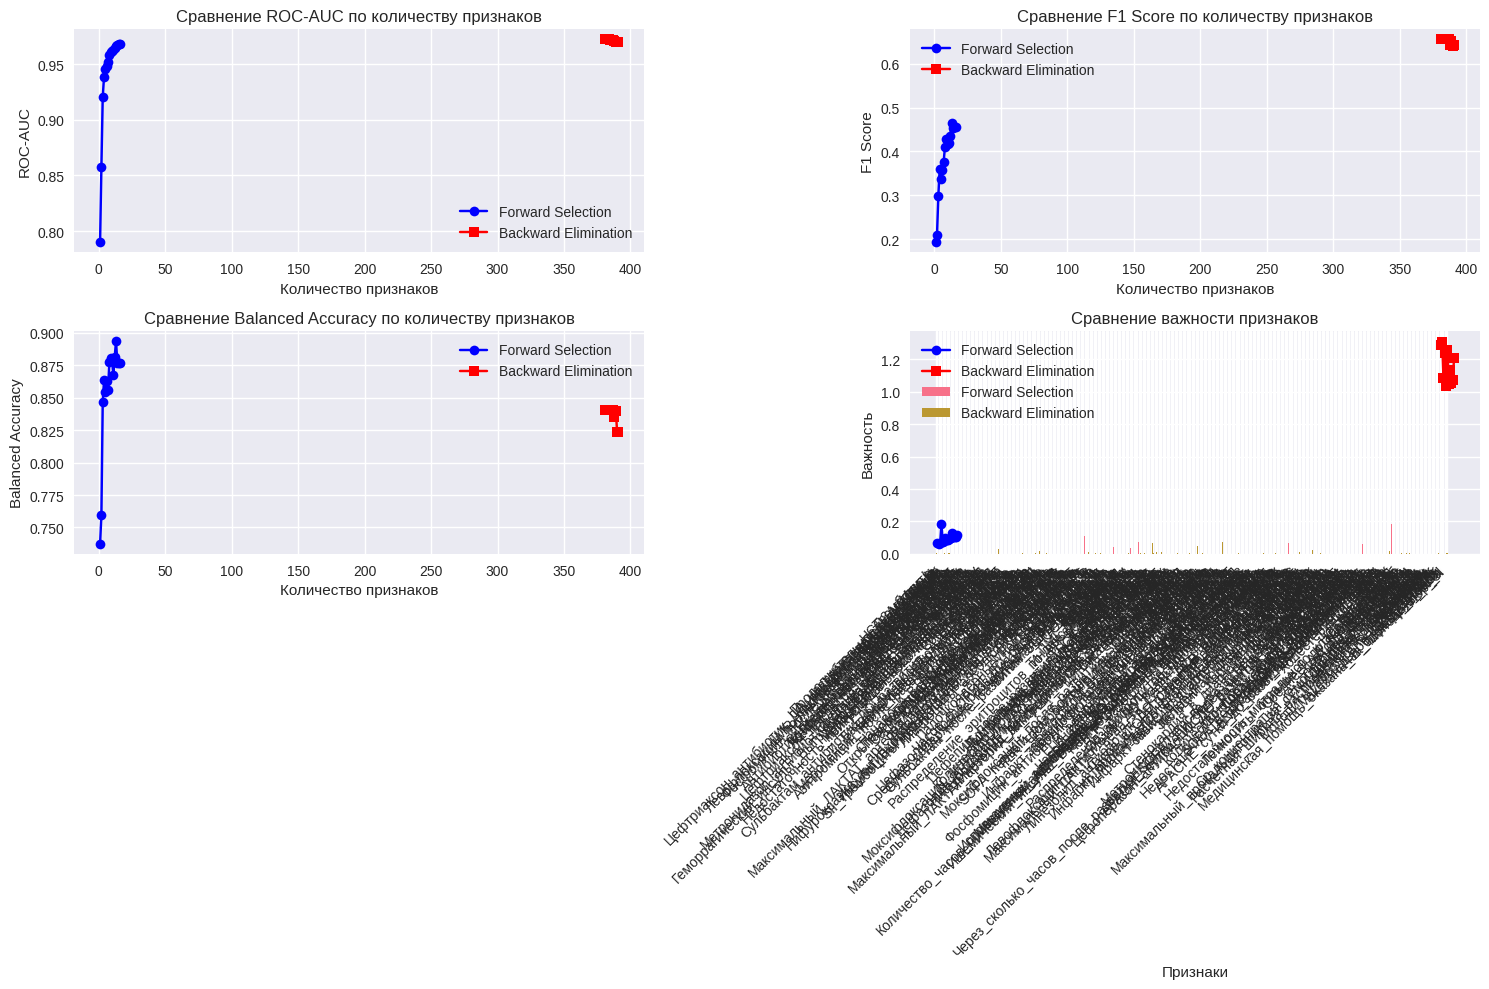

In [267]:
print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
analyzer.compare_feature_selection_methods()

In [268]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='forward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (forward, 16 признаков) ===
По Balanced Accuracy score: 0.2200 (F1=0.9188)
По Youden's J: 0.2240


In [269]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='backward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (backward, 381 признаков) ===
По Balanced Accuracy score: 0.1100 (F1=0.8890)
По Youden's J: 0.0556



=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


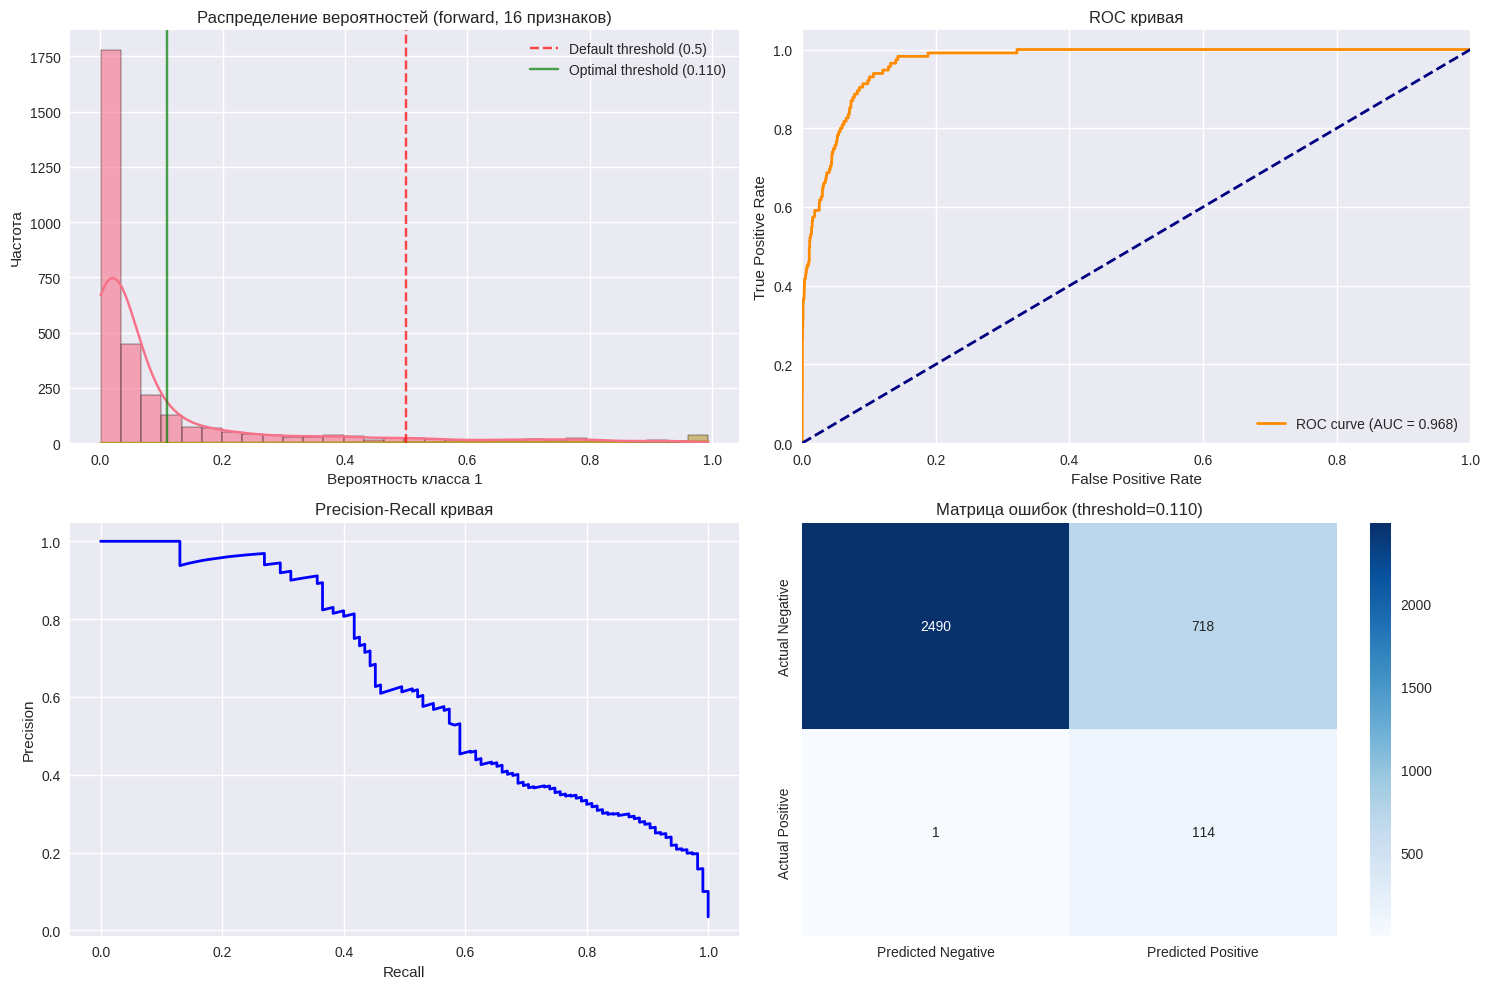

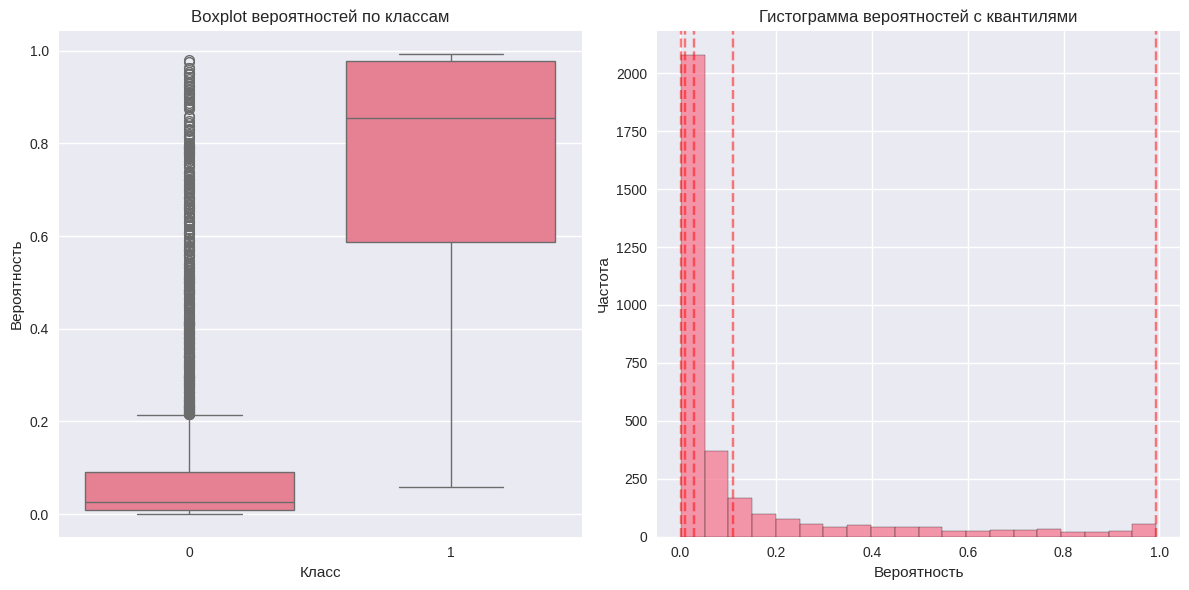

In [270]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='forward')


=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


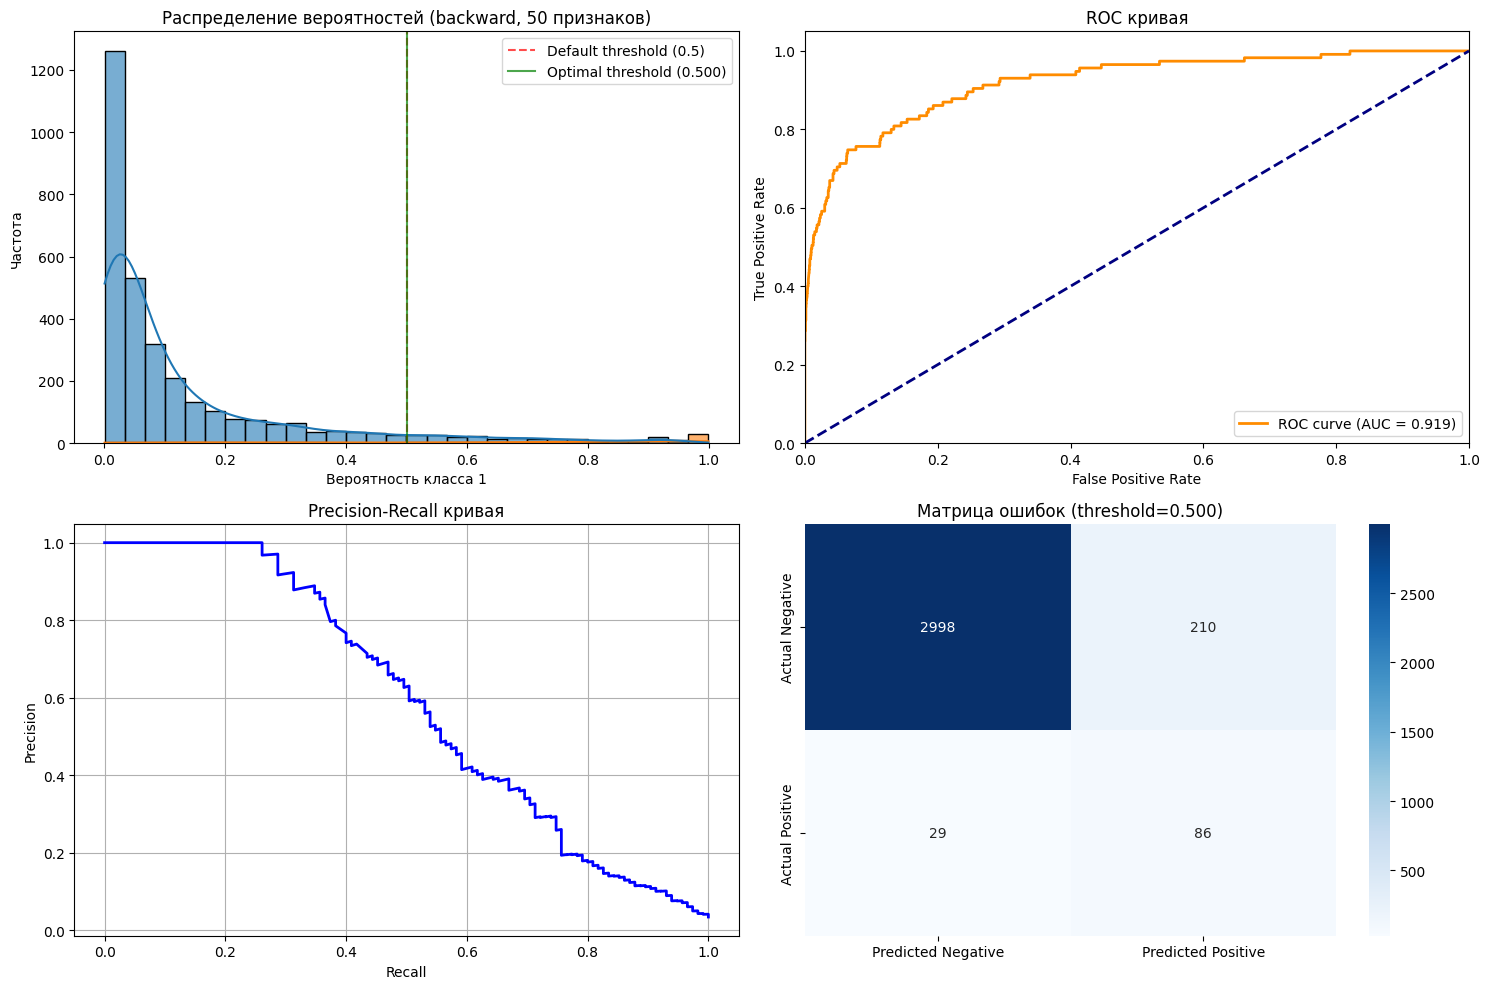

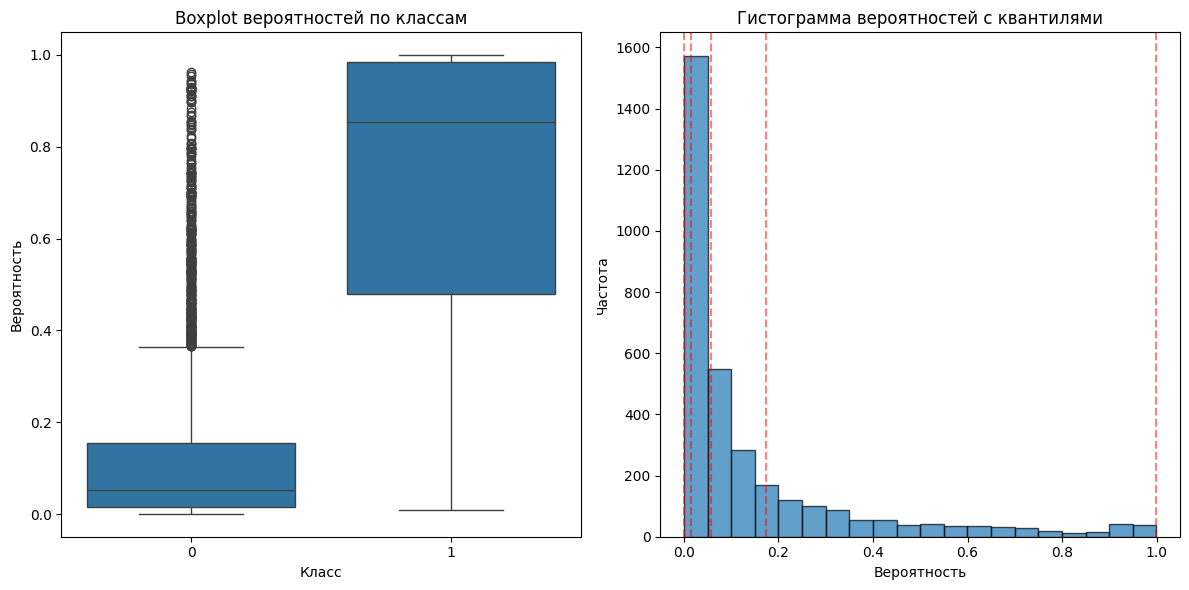

In [ ]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='backward')

In [271]:
# Получение лучших признакей из всех комбинаций
print("\n=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===")
best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')


=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===
=== Лучшие признаки (forward) ===
Количество признаков: 13
Лучшая f1: 0.4656
Признаки: ['Креатинин', 'СДЛА', 'Экстренная_операция_ИБ_Новый', 'BLR_базофилы_абс/лимфоциты_абс', 'ХБП', 'ФП_a_в_анамнезе', 'RLR_RDW/_lymph_abs', 'Моноциты_абсолютное_значение', 'APACHE_сутки_ПОСЛЕ_развития_SOFA_8_и_более', 'Сульбактам_после_развития_SOFA_8_и_более', 'Ср_концентрация_гемоглобина_в_эритроците', 'Сумма_всех_лейкоцитов', 'Индекс_массы_тела']

Важность признаков:
  Экстренная_операция_ИБ_Новый: 0.1946
  Креатинин: 0.1845
  СДЛА: 0.1092
  BLR_базофилы_абс/лимфоциты_абс: 0.0729
  ФП_a_в_анамнезе: 0.0728
  RLR_RDW/_lymph_abs: 0.0684
  ХБП: 0.0633
  Моноциты_абсолютное_значение: 0.0629
  Сульбактам_после_развития_SOFA_8_и_более: 0.0460
  Индекс_массы_тела: 0.0375
  Ср_концентрация_гемоглобина_в_эритроците: 0.0347
  Сумма_всех_лейкоцитов: 0.0340
  APACHE_сутки_ПОСЛЕ_развития_SOFA_8_и_более: 0.0193
=== Лучшие признаки (backward) ===
Количество признаков: 387
Л

In [272]:
print("\n=== ЗАКЛЮЧЕНИЕ ===")
print(f"Лучший ROC AUC (Forward): {best_forward_result['metrics']['roc_auc']:.4f} с {len(best_forward_features)} признаками")
print(f"Лучший ROC AUC (Backward): {best_backward_result['metrics']['roc_auc']:.4f} с {len(best_backward_features)} признаками")
print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")


=== ЗАКЛЮЧЕНИЕ ===
Лучший ROC AUC (Forward): 0.9664 с 13 признаками
Лучший ROC AUC (Backward): 0.9717 с 387 признаками
Оптимальный порог для бинарной классификации: 0.1100


In [273]:
analyzer = FeatureSelectionAnalyzer(X_clean, y, test_size=0.2, random_state=42, categorial_features=cat_features)

In [274]:
print("=== FORWARD SELECTION ===")
forward_features = analyzer.forward_selection(lgb_model, max_features=None, metric='roc_auc')  # ограничим до 10 признакей для демонстрации

=== FORWARD SELECTION ===
Запуск Forward Selection...


  0%|          | 1/392 [00:18<1:58:31, 18.19s/it, roc_auc=0.7920, Features=1]

Step 1: Добавлен признак 'САД_a', roc_auc: 0.7920


  1%|          | 2/392 [00:42<2:21:54, 21.83s/it, roc_auc=0.8789, Features=2]

Step 2: Добавлен признак 'СДЛА', roc_auc: 0.8789


...

Step 13: Добавлен признак 'APACHE_сутки_ПОСЛЕ_развития_SOFA_8_и_более', roc_auc: 0.9744


  4%|▎         | 14/392 [07:38<3:50:35, 36.60s/it, roc_auc=0.9749, Features=14]

Step 14: Добавлен признак 'Левофлоксацин_антибиотик_ДО_развития_SOFA_8_и_более', roc_auc: 0.9749


  4%|▎         | 14/392 [08:15<3:43:03, 35.41s/it, roc_auc=0.9749, Features=14]

Step 15: Нет улучшений, останавливаемся
Forward Selection завершен. Выбрано признаков: 14


In [275]:
print("=== BACKWARD SELECTION ===")
forward_features = analyzer.backward_elimination(lgb_model, min_features=1, metric='roc_auc')  # ограничим до 10 признакей для демонстрации

=== BACKWARD SELECTION ===
Запуск Backward Elimination...


  0%|          | 1/391 [03:54<25:25:00, 234.62s/it, roc_auc=0.9749, Features=391]

Step 1: Удален признак 'АСАТ_a', roc_auc: 0.9749


  1%|          | 2/391 [07:48<25:16:39, 233.93s/it, roc_auc=0.9768, Features=390]

Step 2: Удален признак 'pHARTmin_b', roc_auc: 0.9768


...

Step 9: Удален признак 'ФП_b_после_чкв', roc_auc: 0.9785


  3%|▎         | 10/391 [38:00<23:39:22, 223.52s/it, roc_auc=0.9785, Features=382]

Step 10: Удален признак 'ФВ_ЛЖ_b', roc_auc: 0.9785


  3%|▎         | 10/391 [41:41<26:28:31, 250.16s/it, roc_auc=0.9785, Features=382]

Step 11: Удаление ухудшает результат, останавливаемся
Backward Elimination завершен. Осталось признаков: 382


In [277]:
1

1


=== СРАВНЕНИЕ МЕТОДОВ ===


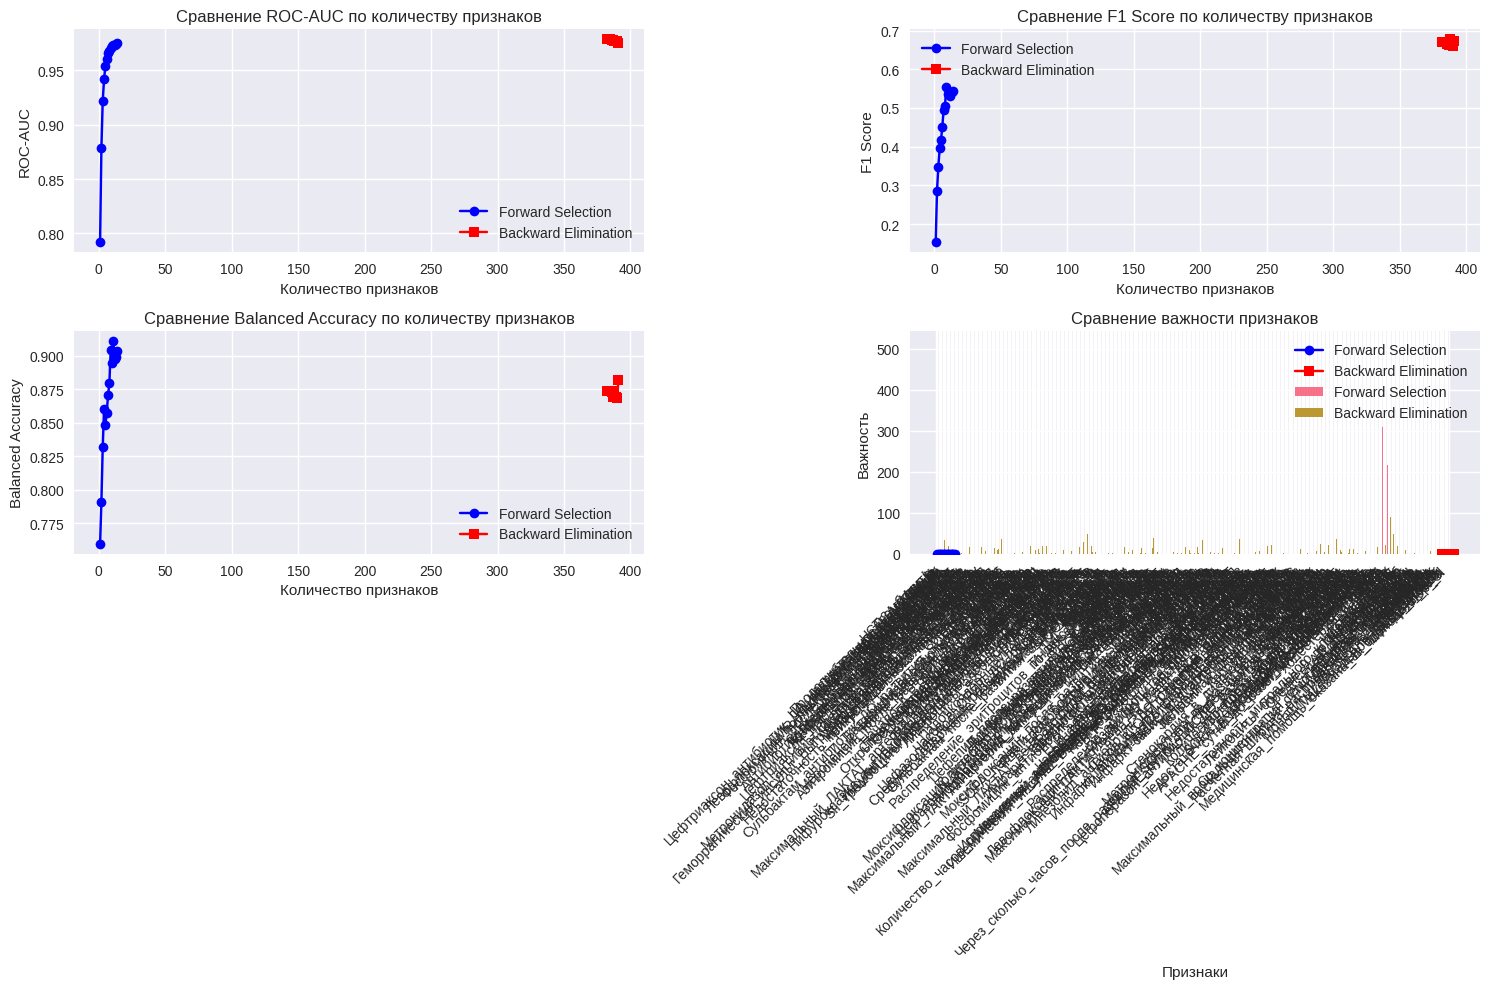

In [278]:
print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
analyzer.compare_feature_selection_methods()

In [279]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='forward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (forward, 14 признаков) ===
По Balanced Accuracy score: 0.1400 (F1=0.9206)
По Youden's J: 0.1777


In [280]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='backward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (backward, 382 признаков) ===
По Balanced Accuracy score: 0.1000 (F1=0.9095)
По Youden's J: 0.0303



=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


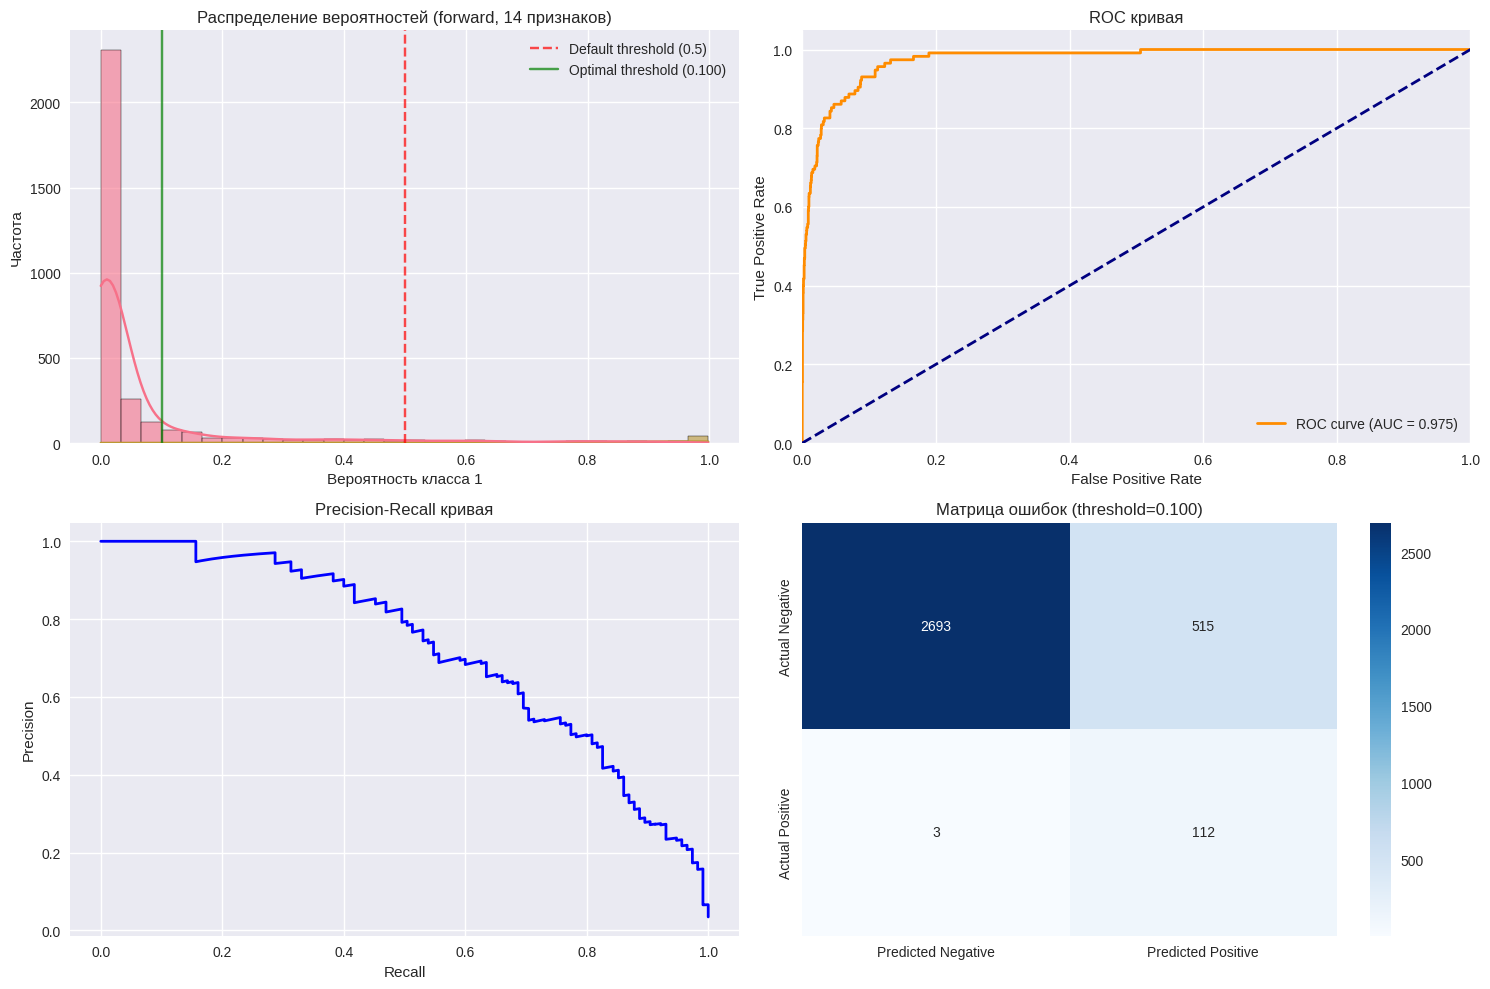

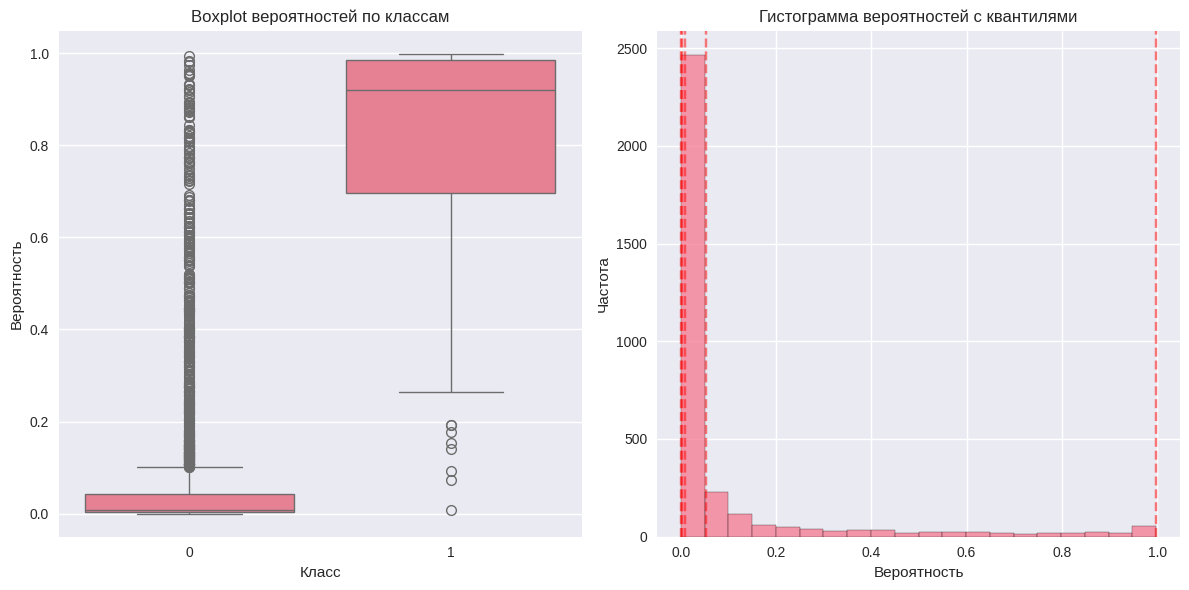

In [281]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='forward')


=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


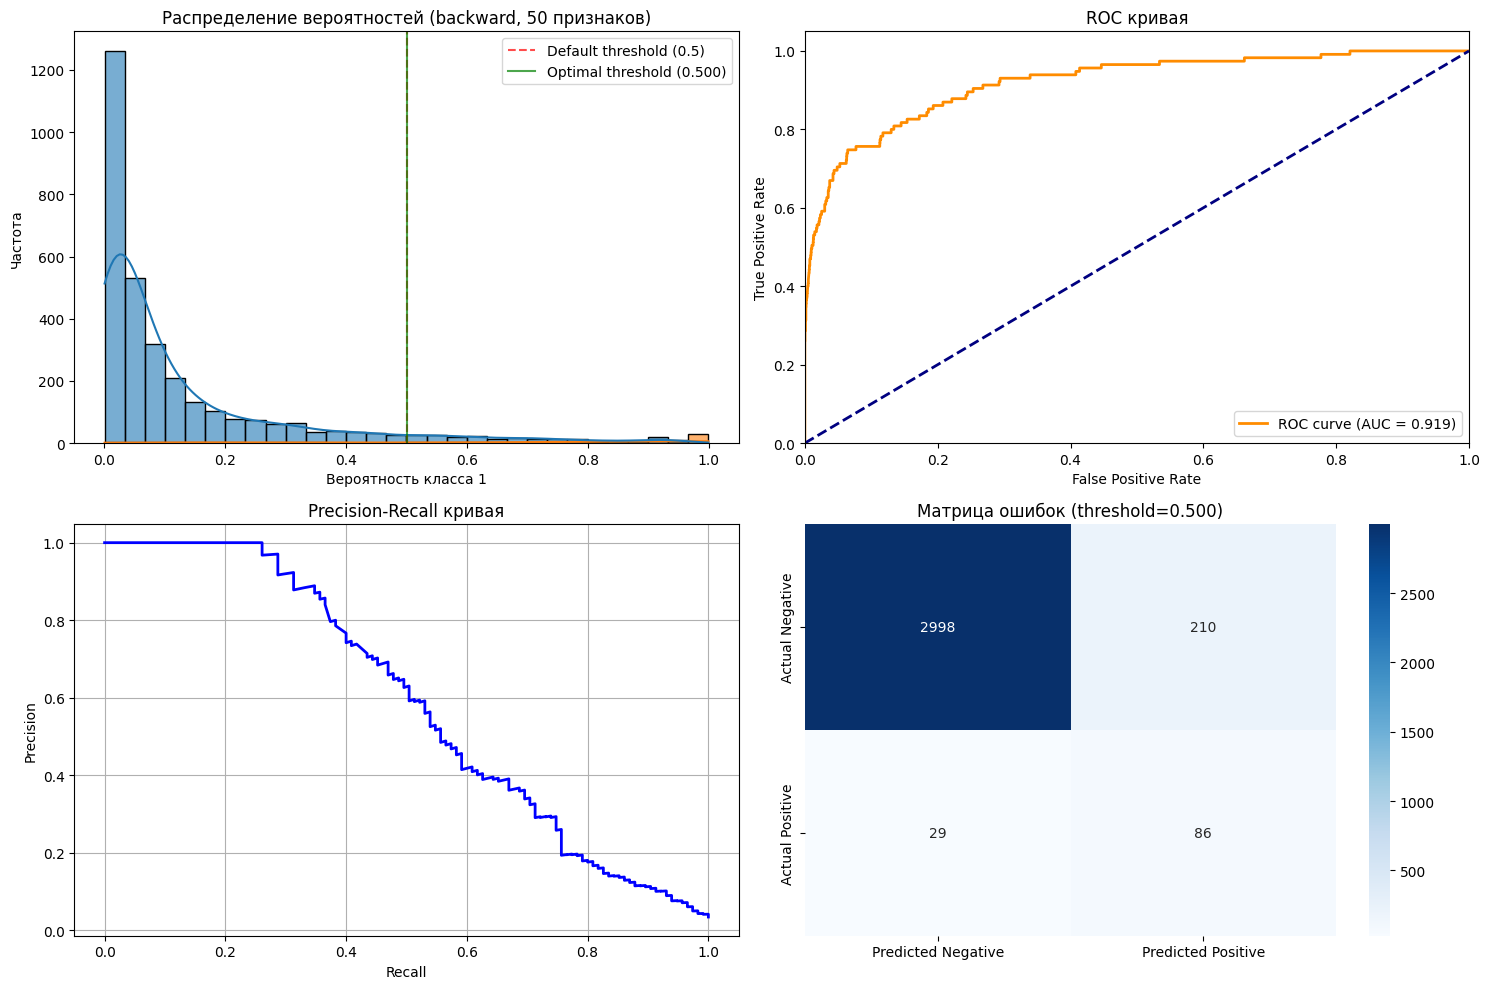

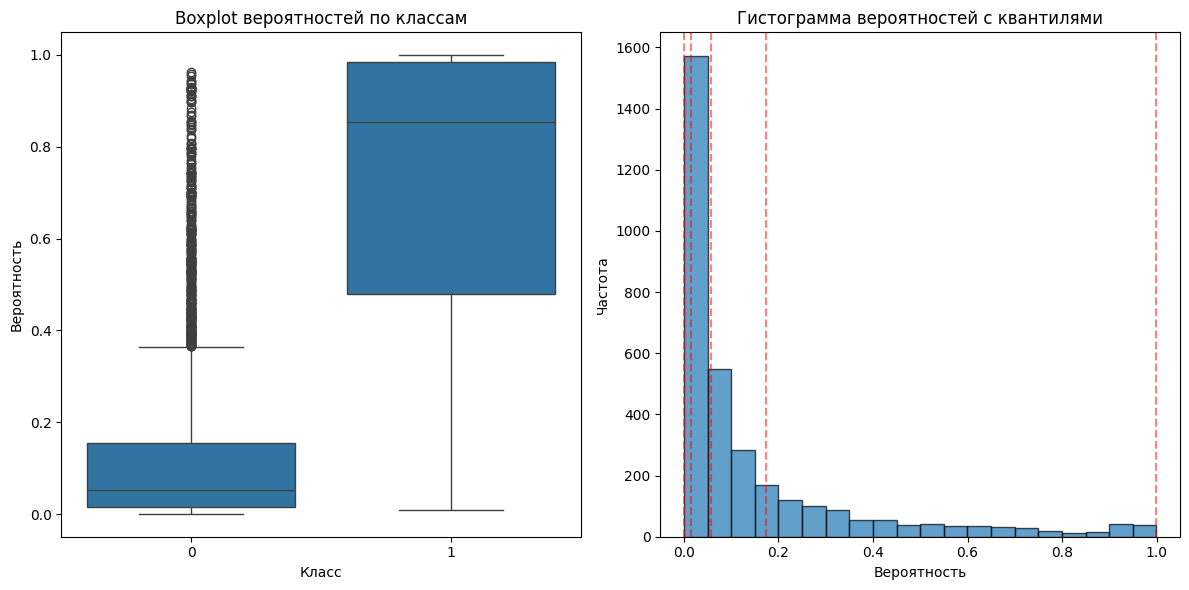

In [ ]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='backward')

In [282]:
# Получение лучших признакей из всех комбинаций
print("\n=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===")
best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')


=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===
=== Лучшие признаки (forward) ===
Количество признаков: 9
Лучшая f1: 0.5552
Признаки: ['САД_a', 'СДЛА', 'MKB', 'Нейтрофилы_абсолютное_значение', 'Инфаркт-зависимая_артерия', 'Age', 'killip', 'ЧСС_а', 'Стенокардия_в_диагнозе_при_поступлении']

Важность признаков:
  Нейтрофилы_абсолютное_значение: 518.0000
  СДЛА: 347.0000
  Age: 309.0000
  САД_a: 216.0000
  MKB: 187.0000
  killip: 182.0000
  ЧСС_а: 166.0000
  Инфаркт-зависимая_артерия: 156.0000
  Стенокардия_в_диагнозе_при_поступлении: 70.0000
=== Лучшие признаки (backward) ===
Количество признаков: 388
Лучшая f1: 0.6769
Признаки: ['Age', 'Sex', 'STEMI', 'ЧКВ', 'Вид_STEMI', 'Инфаркт-зависимая_артерия', 'Поражение_ствола', 'Количество_пораженных_сосудов_Syntax', 'Количество_пораженных_сосудов_Значимость', 'TIMI', 'Инфаркт_миокарда_в_анамнезе_lt_3', 'Инфаркт_миокарда_в_анамнезе_gt_3', 'Инфаркт_миокарда_со_стентированием_в_анамнезе', 'ОНМК_иш_в_анамнезе', 'ОНМК_гем_в_анамнезе', 'Стентирование_в_а

In [283]:
print("\n=== ЗАКЛЮЧЕНИЕ ===")
print(f"Лучший ROC AUC (Forward): {best_forward_result['metrics']['roc_auc']:.4f} с {len(best_forward_features)} признаками")
print(f"Лучший ROC AUC (Backward): {best_backward_result['metrics']['roc_auc']:.4f} с {len(best_backward_features)} признаками")
print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")


=== ЗАКЛЮЧЕНИЕ ===
Лучший ROC AUC (Forward): 0.9706 с 9 признаками
Лучший ROC AUC (Backward): 0.9773 с 388 признаками
Оптимальный порог для бинарной классификации: 0.1000


In [ ]:
print("All worked out")